## COS711 Assignment 3
Automatically labelling radio sources with deep learning

By: xxx

**Project Overview**: This notebook presents a comprehensive deep learning pipeline for the automatic classification of radio sources from the MeerKAT Galaxy Cluster Legacy Survey (MGCLS). The primary challenges include a small labeled dataset, significant class imbalance, and the multi-label nature of the classification task.

Our approach is structured as follows:


1. Data Preparation: We meticulously clean the labels, handle the "Should be Discarded" class as a valid category , and use an efficient cKDTree algorithm to match astronomical coordinates to image files.

2. Baseline Model: We train a powerful pre-trained model (EfficientNetV2) on the initial labeled data, establishing a performance baseline. We explicitly address the class imbalance using a weighted loss function.

3. Enhancement via Pseudo-Labelling: To leverage the large set of unlabeled data, we implement a pseudo-labelling pipeline. We use our baseline model to predict labels for unlabeled images, select the most confident predictions, and then fine-tune a new model on this augmented dataset.


4. Evaluation & Comparison: We rigorously compare the performance of the baseline model against the enhanced pseudo-labeled model to demonstrate the effectiveness of our approach.

5. Final Deliverables: We generate the required test_labels.csv and generated_labels.csv files using our best-performing model.

In [6]:
# Uncomment if you are running before unzipping the images folders. This will extract in same BASE directory 
import os, zipfile
from pathlib import Path

BASE = Path("content/mgcls")
# BASE.mkdir(parents=True, exist_ok=True)

# # Unzip if present
for z in ["typ.zip", "exo.zip", "unl.zip"]:
    zpath = BASE / z
    if zpath.exists():
        with zipfile.ZipFile(zpath, 'r') as zf:
            zf.extractall(BASE / z.replace('.zip',''))
    else:
        print("Warning: missing", zpath)

In [7]:
# Uncomment if running in memory contrained env
# import os
# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
# Unomment out if you want to do the best parameter searching
# !pip install optuna -q
# import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 11.1 MB/s eta 0:00:00


In [8]:
# Cell 1: Project Setup & Imports

# Basic imports for data handling, numerics, and plotting.
import os, zipfile
import random
import math
import re
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from fastprogress import progress_bar
from PIL import Image, UnidentifiedImageError
from scipy.spatial import cKDTree

# Scikit-learn for data splitting and multi-label encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score, multilabel_confusion_matrix, classification_report, f1_score, precision_score, recall_score

# PyTorch for deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# Mixed-precision training for performance
try:
    from torch.cuda.amp import autocast, GradScaler
except ImportError:
    print("Warning: torch.cuda.amp not found. Running without mixed precision.")
    # Dummy classes if amp is not available
    class autocast:
        def __enter__(self): pass
        def __exit__(self, exc_type, exc_val, exc_tb): pass
    class GradScaler:
        def scale(self, loss): return loss
        def step(self, optimizer): optimizer.step()
        def update(self): pass

# --- Deterministic Setup for Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.9.0
CUDA Available: False


In [10]:
# Cell 2: Global Constants and File Paths
# Define constants and paths used throughout the notebook for easy configuration.

# --- Paths ---
# NOTE: Ensure your Google Drive is mounted at /content/drive
BASE_DIR = Path("content/mgcls")
RESULTS_DIR = Path("content/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True) # Create results directory if it doesn't exist

# --- Model & Training Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 384
BATCH_SIZE = 16
LEARNING_RATE_BASELINE = 5e-4
LEARNING_RATE_FINETUNE = 1e-4 # Use a lower LR for fine-tuning with pseudo-labels
WEIGHT_DECAY = 1e-4
EPOCHS = 30 # Max epochs; early stopping will likely trigger before this.
PATIENCE = 7 # For early stopping

print(f"Base data directory: {BASE_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")
print(f"Using device: {DEVICE}")

Base data directory: content/mgcls
Results will be saved to: content/results
Using device: cpu


In [11]:
# Cell 3: Data Loading & Initial Exploration
# Load the metadata files (labels.csv, test.csv) and perform an initial count of the image files.

# --- Load CSVs ---
labels_path = BASE_DIR / "labels.csv"
test_path = BASE_DIR / "test.csv"
assert labels_path.exists(), f"'{labels_path}' not found. Please check the path."
assert test_path.exists(), f"'{test_path}' not found. Please check the path."

labels_df_raw = pd.read_csv(labels_path, header=None, names=["ra", "dec", "label", "col4", "col5"])
test_df = pd.read_csv(test_path) # Header is inferred correctly

print(f"labels.csv initial shape: {labels_df_raw.shape}")
display(labels_df_raw.head())
print(f"\ntest.csv shape: {test_df.shape}")
display(test_df.head())

# --- Count Image Files ---
typ_count = len(list((BASE_DIR/"typ").rglob("*.*")))
exo_count = len(list((BASE_DIR/"exo").rglob("*.*")))
unl_count = len(list((BASE_DIR/"unl").rglob("*.*")))
print(f"\nFound {typ_count} typical source files.")
print(f"Found {exo_count} exotic source files.")
print(f"Found {unl_count} unlabelled source files.")

labels.csv initial shape: (2178, 5)


,ra,dec,label,col4,col5
0,10.328221,-20.476357,FR II,NaN,NaN
1,92.109802,-49.431413,typical,NaN,NaN
2,88.916825,-59.431868,Point Source,NaN,NaN
3,5.457981,-25.589637,FR II,NaN,NaN
4,119.417608,-53.396711,FR II,NaN,NaN



test.csv shape: (99, 2)


,201.7436567,-31.32163727
0,234.261286,-46.590846
1,66.793081,-62.375058
2,108.760518,-59.958776
3,202.148240,-31.432391
4,57.025208,-73.861150



Found 2049 typical source files.
Found 72 exotic source files.
Found 13821 unlabelled source files.


In [12]:
# Cell 4: Label Cleaning and Preprocessing
# As per the assignment, we need to handle labels carefully.
# We will NOT remove the 'Should be discarded' class, as the model must be able to identify these images.
# Our preprocessing involves cleaning up unused columns and standardizing the label text format.

# Drop unused columns and rows with missing essential data
labels_df = labels_df_raw[["ra", "dec", "label"]].dropna().copy()

# Standardize label text: title case, strip whitespace, and normalize separators
labels_df["label"] = (
    labels_df["label"]
    .str.strip()
    .str.replace("-", " ", regex=False)
    .str.replace("/", " ", regex=False)
    .str.title() # e.g., 'FR II' -> 'Fr Ii', 'S/Z shaped' -> 'S Z Shaped'
)

print(f"Cleaned labels count: {len(labels_df)}")
print("\nUnique cleaned labels:")
unique_labels = sorted(labels_df["label"].unique())
for label in unique_labels:
    print(f"- {label}")

# We confirm that 'Should Be Discarded' is retained as a valid class.
assert 'Should Be Discarded' in unique_labels

Cleaned labels count: 2178

Unique cleaned labels:
- Bent
- Exotic
- Fr I
- Fr Ii
- Point Source
- S Z Shaped
- Should Be Discarded
- Typical
- X Shaped


In [13]:
# Cell 5: Image File Discovery and Coordinate Extraction
# We need to map labels to images via coordinates.
# First, we'll recursively find all image files and extract coordinates from their filenames.
# The filenames contain coordinates, but they are not always an exact match to the label coordinates.

def extract_coords_from_filename(fname):
    """Extracts the first two floating-point numbers (RA, Dec) from a filename string."""
    name = Path(fname).stem
    # Regex to find floating-point numbers, including negative ones
    nums = re.findall(r"-?\d+\.\d+", name)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None # Return None if coords can't be found

# Find all image files in 'typ', 'exo', and 'unl' directories
all_images = []
for subset in ["typ", "exo", "unl"]:
    subset_path = BASE_DIR / subset
    for f in subset_path.rglob("*"):
        if f.suffix.lower() in [".png", ".jpg", ".jpeg"] and f.is_file():
            coords = extract_coords_from_filename(f.name)
            if coords: # Only include images where coordinates could be extracted
                all_images.append({
                    "filepath": str(f),
                    "subset": subset,
                    "coords": coords
                })

images_df = pd.DataFrame(all_images)
print(f"Found {len(images_df)} total images with extractable coordinates.")
# print(f"From {typ_count + exo_count + unl_count} we matched {len(images_df)} images.\n We couldn't get {(typ_count + exo_count + unl_count) - {len(images_df)}} images via cordinates")
display(images_df.head())

Found 15941 total images with extractable coordinates.


,filepath,subset,coords
0,content/mgcls/typ/typ_PNG/302.069 -56.976_[0.0...,typ,"(302.069, -56.976)"
1,content/mgcls/typ/typ_PNG/99.794 -48.029_[0.06...,typ,"(99.794, -48.029)"
2,content/mgcls/typ/typ_PNG/91.024 -49.967_[0.00...,typ,"(91.024, -49.967)"
3,content/mgcls/typ/typ_PNG/2.636 -19.068_[0.018...,typ,"(2.636, -19.068)"
4,content/mgcls/typ/typ_PNG/90.953 -40.584_[0.00...,typ,"(90.953, -40.584)"


In [14]:
# Cell 6: Coordinate Matching using k-d Tree
# To solve the inexact coordinate matching problem, we use a k-d tree.
# This is a highly efficient data structure for finding the nearest neighbor in a multi-dimensional space.
# We build a tree from all image coordinates and query it with each label's coordinates to find the closest image file.

# Separate labeled images (typ, exo) from unlabeled (unl)
labeled_images_df = images_df[images_df['subset'].isin(['typ', 'exo'])].copy()

# Build the k-d tree on the coordinates of labeled images
image_coords = np.array(labeled_images_df['coords'].tolist())
kdtree = cKDTree(image_coords)

# For each label, find the closest image in the k-d tree
label_coords = labels_df[['ra', 'dec']].values
distances, indices = kdtree.query(label_coords, k=1)

# Assign the matched filepath to each label
labels_df['filepath'] = labeled_images_df.iloc[indices]['filepath'].values

print("Matched labels to their closest image files.")
display(labels_df[['ra', 'dec', 'label', 'filepath']].head())

Matched labels to their closest image files.


,ra,dec,label,filepath
0,10.328221,-20.476357,Fr Ii,content/mgcls/typ/typ_PNG/10.328 -20.476_[0.01...
1,92.109802,-49.431413,Typical,content/mgcls/typ/typ_PNG/92.110 -49.431_[0.04...
2,88.916825,-59.431868,Point Source,content/mgcls/typ/typ_PNG/88.917 -59.432_[0.00...
3,5.457981,-25.589637,Fr Ii,content/mgcls/typ/typ_PNG/5.458 -25.590_[0.009...
4,119.417608,-53.396711,Fr Ii,content/mgcls/typ/typ_PNG/119.418 -53.397_[0.0...


In [15]:
# Cell 7: Final DataFrame Preparation and Multi-Label Encoding
# The problem is multi-label, as some sources have multiple classifications (e.g., 'FR I' and 'Bent')[cite: 48].
# We group the labels by filepath and then use MultiLabelBinarizer to create a one-hot encoded vector for each image.

# Group labels by the matched filepath
grouped_labels = labels_df.groupby('filepath')['label'].apply(list).reset_index()

# Merge the grouped labels back into the main labeled images dataframe
# We use a 'left' merge to keep all images, even those with no matching label (they will get an empty list).
merged_df = pd.merge(labeled_images_df, grouped_labels, on='filepath', how='left')
# Fill NaN labels (images with no match) with an empty list for the binarizer
merged_df['label'] = merged_df['label'].apply(lambda x: x if isinstance(x, list) else [])

# --- Multi-Label Binarization ---
mlb = MultiLabelBinarizer()
multi_hot_labels = mlb.fit_transform(merged_df['label'])
merged_df['multi_hot'] = list(multi_hot_labels)

# Save the classes found by the binarizer for later use
LABEL_CLASSES = mlb.classes_.tolist()

print(f"DataFrame prepared for training with {len(merged_df)} labeled images.")
print(f"Found {len(LABEL_CLASSES)} unique classes:")
print(LABEL_CLASSES)
display(merged_df[['filepath', 'label', 'multi_hot']].head())

DataFrame prepared for training with 2120 labeled images.
Found 9 unique classes:
['Bent', 'Exotic', 'Fr I', 'Fr Ii', 'Point Source', 'S Z Shaped', 'Should Be Discarded', 'Typical', 'X Shaped']


,filepath,label,multi_hot
0,content/mgcls/typ/typ_PNG/302.069 -56.976_[0.0...,[Bent],"[1, 0, 0, 0, 0, 0, 0, 0, 0]"
1,content/mgcls/typ/typ_PNG/99.794 -48.029_[0.06...,[Fr I],"[0, 0, 1, 0, 0, 0, 0, 0, 0]"
2,content/mgcls/typ/typ_PNG/91.024 -49.967_[0.00...,[Fr I],"[0, 0, 1, 0, 0, 0, 0, 0, 0]"
3,content/mgcls/typ/typ_PNG/2.636 -19.068_[0.018...,"[Fr Ii, Fr Ii]","[0, 0, 0, 1, 0, 0, 0, 0, 0]"
4,content/mgcls/typ/typ_PNG/90.953 -40.584_[0.00...,[],"[0, 0, 0, 0, 0, 0, 0, 0, 0]"


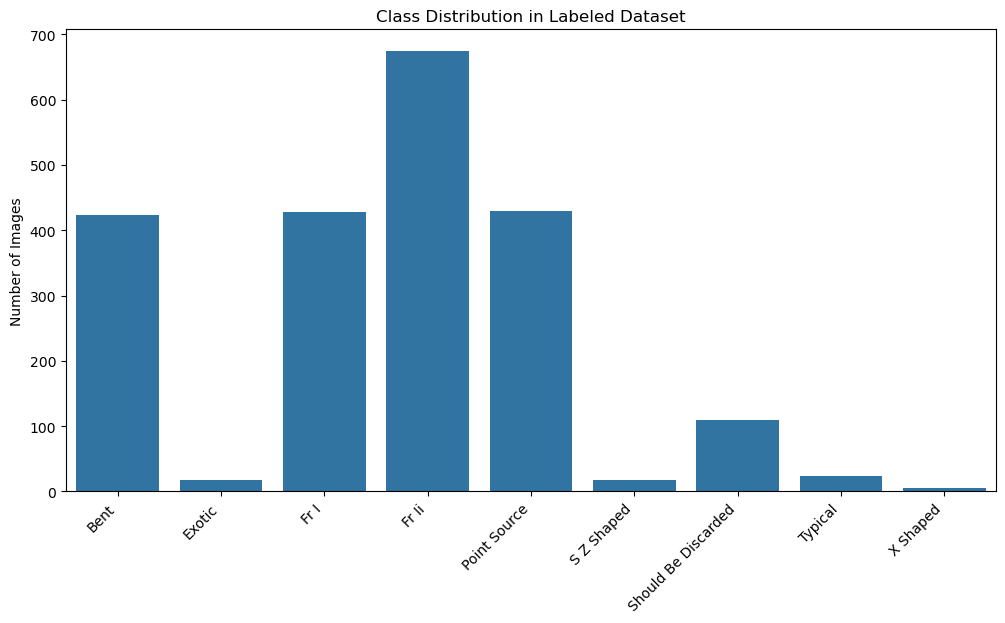

Calculated positive weights for BCEWithLogitsLoss to handle class imbalance:
- Bent: 4.01
- Exotic: 30.00
- Fr I: 3.95
- Fr Ii: 2.15
- Point Source: 3.94
- S Z Shaped: 30.00
- Should Be Discarded: 18.45
- Typical: 30.00
- X Shaped: 30.00


In [16]:
# Cell 8: Addressing Class Imbalance with Weighted Loss
# The dataset is highly imbalanced, with many 'FR I/II' sources and very few 'X-Shaped' ones.
# To prevent the model from ignoring rare classes, we will use a weighted loss function.
# The weight for each class is the inverse of its frequency, encouraging the model to pay more attention to under-represented classes.

class_counts = merged_df['multi_hot'].sum(axis=0)
class_frequencies = class_counts / len(merged_df)

# Calculate positive weights for BCEWithLogitsLoss
pos_weight = (len(merged_df) - class_counts) / (class_counts + 1e-9)
pos_weight = np.clip(pos_weight, None, 30.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

# Define the weighted loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# --- Visualize Class Distribution ---
plt.figure(figsize=(12, 6))
sns.barplot(x=LABEL_CLASSES, y=class_counts)
plt.title('Class Distribution in Labeled Dataset')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.show()

print("Calculated positive weights for BCEWithLogitsLoss to handle class imbalance:")
for cls, weight in zip(LABEL_CLASSES, pos_weight):
    print(f"- {cls}: {weight:.2f}")


In [ ]:
# Cell 9: Dataset, Data Augmentation, and DataLoaders
# We define advanced data augmentations to artificially expand the small training set and improve model generalization[cite: 31, 63].
# We then create PyTorch Dataset and DataLoader objects to feed data to the model efficiently.

# --- Data Augmentation Transforms ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7,1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- PyTorch Dataset Class ---
class RadioDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['filepath']
        try:
            img = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError):
            # If an image is corrupt, load the next one instead.
            return self.__getitem__((idx + 1) % len(self.df))

        if self.transform:
            img = self.transform(img)

        target = torch.tensor(row['multi_hot'], dtype=torch.float32)
        return img, target

# --- Train/Validation Split ---
train_df, val_df = train_test_split(merged_df, test_size=0.15, random_state=SEED)
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")

# --- Create DataLoaders ---
train_dataset = RadioDataset(train_df, transform=train_transforms)
val_dataset = RadioDataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Test one batch to ensure it works
imgs, targets = next(iter(train_loader))
print(f"\nBatch of images shape: {imgs.shape}")
print(f"Batch of targets shape: {targets.shape}")

Training set size: 1802
Validation set size: 318


/opt/homebrew/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=78, pipe_handle=92)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'RadioDataset' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


In [15]:
# Cell 10: Model Architecture Definition
# We define functions to get two powerful pre-trained models: EfficientNetV2-S and EfficientNetV2-M
# We will compare their performance to select the best one for our task.
# The final classification layer of each model is replaced to match our number of classes.

def get_efficientnet_v2(n_classes):
    """Loads a pre-trained EfficientNetV2-S and adapts its classifier."""
    try:
        model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
    except TypeError: # Fallback for older torchvision
        model = models.efficientnet_v2_s(pretrained=True)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, n_classes)
    return model.to(DEVICE)

def get_efficientnetv2(n_classes):
    """Loads a pre-trained EfficientNetV2-M and adapts its classifier."""
    try:
        model = models.efficientnet_v2_m(weights='IMAGENET1K_V1')
    except TypeError:
        model = models.efficientnet_v2_m(pretrained=True)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, n_classes)
    return model.to(DEVICE)

# --- Early Stopping Utility ---
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = None
        self.counter = 0

    def step(self, metric):
        if self.best_metric is None or metric > self.best_metric + self.min_delta:
            self.best_metric = metric
            self.counter = 0
            return False # Continue training
        else:
            self.counter += 1
            return self.counter >= self.patience # Stop training

In [16]:
# Cell 11: Training, Evaluation, and Optimization Utilities

# --- Main Evaluation Function ---
def evaluate_model(loader, model, criterion, device=DEVICE, threshold=0.5, return_details=False):
    """Evaluates the model on a given dataset loader, returning loss and several metrics."""
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            if isinstance(y, torch.Tensor):
                y = y.to(device)
            else:
                y = torch.tensor(y, device=device)

            logits = model(x)

            if isinstance(criterion, (nn.BCEWithLogitsLoss, LabelSmoothingBCEWithLogitsLoss)):
                y_for_loss = y.float()
            else:
                y_for_loss = y.long()

            loss = criterion(logits, y_for_loss)
            total_loss += float(loss.detach().cpu()) * x.size(0)

            all_logits.append(logits.cpu())
            all_targets.append(y.cpu())

    avg_loss = total_loss / len(loader.dataset)
    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    if isinstance(criterion, (nn.BCEWithLogitsLoss, LabelSmoothingBCEWithLogitsLoss)):
        probs = torch.sigmoid(all_logits)
        # Allow for per-class thresholds
        preds = (probs >= torch.tensor(threshold, dtype=torch.float32)).int()
        true = all_targets.int()
        per_class_f1 = f1_score(true.numpy(), preds.numpy(), average=None, zero_division=0)
        macro_f1 = f1_score(true.numpy(), preds.numpy(), average='macro', zero_division=0)
        micro_f1 = f1_score(true.numpy(), preds.numpy(), average='micro', zero_division=0)
        exact_match = (preds == true).all(dim=1).float().mean().item()
        metrics = {
            'val_loss': avg_loss,
            'macro_f1': float(macro_f1),
            'micro_f1': float(micro_f1),
            'exact_match': float(exact_match),
            'per_class_f1': per_class_f1
        }
    else: # Single-label path (remains for flexibility)
        probs = torch.softmax(all_logits, dim=1)
        preds = probs.argmax(dim=1)
        true = all_targets.long()
        acc = (preds == true).float().mean().item()
        macro_f1 = f1_score(true.numpy(), preds.numpy(), average='macro', zero_division=0)
        metrics = {'val_loss': avg_loss, 'accuracy': float(acc), 'macro_f1': float(macro_f1)}

    if return_details:
        return metrics, preds, true, probs
    return metrics

# --- Post-Training Threshold Optimization ---
def find_best_thresholds(model, val_loader, device=DEVICE):
    """Finds the optimal per-class threshold to maximize F1-score on the validation set."""
    model.eval()
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for imgs, targets in val_loader:
            logits = model(imgs.to(device))
            probs = torch.sigmoid(logits).cpu()
            all_probs.append(probs)
            all_targets.append(targets)

    all_probs = torch.cat(all_probs).numpy()
    all_targets = torch.cat(all_targets).numpy()

    best_thresholds = np.zeros(all_probs.shape[1])
    best_f1s = np.zeros(all_probs.shape[1])

    print("🚀 Finding optimal threshold for each class...")
    for i in range(all_probs.shape[1]): # Iterate over each class
        thresholds = np.linspace(0.05, 0.95, 100)
        f1_scores = [f1_score(all_targets[:, i], (all_probs[:, i] >= t).astype(int), zero_division=0) for t in thresholds]
        best_t_idx = np.argmax(f1_scores)
        best_thresholds[i] = thresholds[best_t_idx]
        best_f1s[i] = f1_scores[best_t_idx]
        print(f"- Class '{LABEL_CLASSES[i]}': Best Threshold = {best_thresholds[i]:.2f} (F1 = {best_f1s[i]:.4f})")

    return best_thresholds

# --- Regularization Helper Functions ---
def mixup_data(x, y, alpha=0.4, device='cuda'):
    if alpha > 0: lam = np.random.beta(alpha, alpha)
    else: lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# --- Main Training Function (with OneCycleLR) ---
def train_model(model, train_loader, val_loader,
                epochs=25, head_epochs=5, head_lr=1e-3, finetune_max_lr=3e-4,
                weight_decay=1e-3, patience=8, device=DEVICE, grad_clip=1.0,
                model_save_path='best_model.pth',
                use_label_smoothing=False, smoothing_factor=0.1,
                use_mixup=False, mixup_alpha=0.4,
                accumulation_steps=1):

    model = model.to(device)

    # --- Loss Function Setup ---
    if use_label_smoothing:
        print(f"Using Label Smoothing with factor {smoothing_factor}")
        criterion = LabelSmoothingBCEWithLogitsLoss(smoothing=smoothing_factor).to(device)
    else:
        class_counts = train_df['multi_hot'].sum(axis=0)
        pos_weight = (len(train_df) - class_counts) / (class_counts + 1e-9)
        pos_weight = np.clip(pos_weight, None, 30.0)
        pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    scaler = GradScaler()
    history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': []}
    stopper = EarlyStopping(patience=patience)
    best_val_f1 = -1.0

    def _train_one_epoch(current_optimizer, scheduler=None, use_mixup_epoch=False):
        model.train()
        running_loss = 0.0
        n_samples = 0
        pbar = progress_bar(train_loader, parent=None)
        current_optimizer.zero_grad()

        for i, (xb, yb) in enumerate(pbar):
            xb, yb = xb.to(device), yb.to(device).float()

            with autocast():
                if use_mixup_epoch:
                    mixed_xb, yb_a, yb_b, lam = mixup_data(xb, yb, alpha=mixup_alpha, device=device)
                    logits = model(mixed_xb)
                    loss = mixup_criterion(criterion, logits, yb_a, yb_b, lam)
                else:
                    logits = model(xb)
                    loss = criterion(logits, yb)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0:
                scaler.unscale_(current_optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(current_optimizer)
                scaler.update()
                if scheduler:
                    scheduler.step()
                current_optimizer.zero_grad()

            running_loss += float(loss.detach().cpu()) * xb.size(0) * accumulation_steps
            n_samples += xb.size(0)
        return running_loss / n_samples

    # --- Phase A: Head Training ---
    print("--- 🧠 Starting Head Training ---")
    try:
        for n, p in model.named_parameters(): p.requires_grad = False
        for p in model.classifier.parameters(): p.requires_grad = True
    except:
        for n, p in model.named_parameters(): p.requires_grad = 'classifier' in n or 'fc' in n or 'head' in n

    head_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(head_params, lr=head_lr, weight_decay=weight_decay)

    for e in range(head_epochs):
        train_loss = _train_one_epoch(optimizer, scheduler=None, use_mixup_epoch=False)
        val_metrics = evaluate_model(val_loader, model, criterion, device=device)
        val_f1 = val_metrics.get('macro_f1', 0.0)
        print(f"[Head] Epoch {e+1}/{head_epochs} | train_loss={train_loss:.4f} | val_macro_f1={val_f1:.4f} | val_loss={val_metrics['val_loss']:.4f}")

    # --- Phase B: Fine-tuning ---
    print("\n--- 🔥 Starting Full Fine-Tuning ---")
    for p in model.parameters(): p.requires_grad = True
    optimizer = AdamW(model.parameters(), lr=finetune_max_lr, weight_decay=weight_decay) # LR is the max_lr for OneCycle

    total_ft_epochs = max(1, epochs - head_epochs)

    scheduler = OneCycleLR(optimizer, max_lr=finetune_max_lr,
                           steps_per_epoch=(len(train_loader) // accumulation_steps),
                           epochs=total_ft_epochs, pct_start=0.3)

    for e in range(total_ft_epochs):
        train_loss = _train_one_epoch(optimizer, scheduler=scheduler, use_mixup_epoch=use_mixup)
        val_metrics = evaluate_model(val_loader, model, criterion, device=device)
        val_f1 = val_metrics.get('macro_f1', 0.0)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['val_macro_f1'].append(val_f1)

        print(f"[Finetune] Epoch {e+1}/{total_ft_epochs} | train_loss={train_loss:.4f} | val_macro_f1={val_f1:.4f} | val_loss={val_metrics['val_loss']:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), model_save_path)
            print(f"   >>> 💾 New best model saved with val_macro_f1: {best_val_f1:.4f} <<<")

        if stopper.step(val_f1):
            print("🛑 Early stopping triggered during finetuning.")
            break

    return model, history

In [17]:
import torch.nn as nn
import numpy as np

class LabelSmoothingBCEWithLogitsLoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingBCEWithLogitsLoss, self).__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        # Apply label smoothing
        targets_smooth = targets * (1.0 - self.smoothing) + self.smoothing / targets.size(1)

        # Get the pos_weight from the original criterion if it exists
        # This assumes 'criterion' is in the global scope from the setup cell
        try:
            pos_weight = criterion.pos_weight
            loss = self.bce(inputs, targets_smooth)
            # Manually apply pos_weight
            loss = loss * (pos_weight * targets + (1 - targets))
        except (NameError, AttributeError):
            # Fallback if original criterion or pos_weight isn't available
            loss = self.bce(inputs, targets_smooth)

        return loss.mean()

In [18]:
# Cell 12: Execute Focused Baseline Training Run & Final Evaluation

# --- 1. Define Hyperparameters from Best Optuna Trial ---
# Sourced from your best trial results
best_params = {
    'finetune_max_lr': 2.5578e-4,
    'weight_decay': 1.3506e-4,
    'mixup_alpha': 0.1143,
    'smoothing_factor': 0.1668
}
print("🚀 Starting focused training run with the following hyperparameters:")
for key, value in best_params.items():
    print(f"  - {key}: {value}")

# --- 2. Initialize Model ---
baseline_model = get_efficientnetv2(len(LABEL_CLASSES))
baseline_model_path = RESULTS_DIR / 'best_baseline_model_onecycle.pth'

# --- 3. Execute the Training Run ---
# This will use the new train_model function with OneCycleLR
baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=40, # Train for a longer duration; early stopping will handle the rest
    head_epochs=5,
    head_lr=1e-3,
    finetune_max_lr=best_params['finetune_max_lr'],
    weight_decay=best_params['weight_decay'],
    patience=8, # A reasonable patience for a full run
    model_save_path=baseline_model_path,
    use_label_smoothing=True,
    smoothing_factor=best_params['smoothing_factor'],
    use_mixup=True,
    mixup_alpha=best_params['mixup_alpha'],
    accumulation_steps=4
)

print(f"\n✅ Training complete. Best baseline model saved to {baseline_model_path}")

🚀 Starting focused training run with the following hyperparameters:
  - finetune_max_lr: 0.00025578
  - weight_decay: 0.00013506
  - mixup_alpha: 0.1143
  - smoothing_factor: 0.1668
Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:01<00:00, 194MB/s]


Using Label Smoothing with factor 0.1668
--- 🧠 Starting Head Training ---


/tmp/ipython-input-2987465467.py:129: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


/tmp/ipython-input-2987465467.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

[Finetune] Epoch 19/35 | train_loss=0.6915 | val_macro_f1=0.3087 | val_loss=0.7173


/tmp/ipython-input-2987465467.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Finetune] Epoch 20/35 | train_loss=0.6783 | val_macro_f1=0.3020 | val_loss=0.7035


/tmp/ipython-input-2987465467.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Finetune] Epoch 21/35 | train_loss=0.6781 | val_macro_f1=0.3083 | val_loss=0.7191
🛑 Early stopping triggered during finetuning.

✅ Training complete. Best baseline model saved to /content/drive/MyDrive/UP Honours/COS711 - AI/Final Results/best_baseline_model_onecycle.pth


In [19]:
# Cell 13:  Baseline's Final Evaluation
# --- 4. Post-Training Optimization and Final Evaluation ---
print("\n--- Evaluating Final Baseline Model with Optimized Thresholds ---")

# Load the best performing weights from the training run
final_model = get_efficientnetv2(len(LABEL_CLASSES))
final_model.load_state_dict(torch.load(baseline_model_path))
final_model.to(DEVICE)

# Find the optimal per-class thresholds on the validation set
best_thresholds = find_best_thresholds(final_model, val_loader)

# Create a dummy criterion instance for the evaluation function.
# Its parameters don't affect metric calculation, only the loss value.
final_criterion = nn.BCEWithLogitsLoss()

# Re-evaluate using the newly found best thresholds
final_metrics = evaluate_model(
    val_loader,
    final_model,
    final_criterion,
    device=DEVICE,
    threshold=best_thresholds # Pass the array of optimal thresholds
)

print("\n--- 📊 Final Baseline Performance ---")
print(f"  - Validation Loss: {final_metrics['val_loss']:.4f}")
print(f"  - Macro F1-Score (Optimized Thresholds): {final_metrics['macro_f1']:.4f}")
print(f"  - Micro F1-Score (Optimized Thresholds): {final_metrics['micro_f1']:.4f}")
print(f"  - Exact Match Ratio: {final_metrics['exact_match']:.4f}")


--- Evaluating Final Baseline Model with Optimized Thresholds ---
🚀 Finding optimal threshold for each class...
- Class 'Bent': Best Threshold = 0.42 (F1 = 0.5224)
- Class 'Exotic': Best Threshold = 0.61 (F1 = 0.5000)
- Class 'Fr I': Best Threshold = 0.52 (F1 = 0.6456)
- Class 'Fr Ii': Best Threshold = 0.55 (F1 = 0.6977)
- Class 'Point Source': Best Threshold = 0.60 (F1 = 0.7059)
- Class 'S Z Shaped': Best Threshold = 0.68 (F1 = 0.1818)
- Class 'Should Be Discarded': Best Threshold = 0.54 (F1 = 0.2000)
- Class 'Typical': Best Threshold = 0.64 (F1 = 0.3077)
- Class 'X Shaped': Best Threshold = 0.05 (F1 = 0.0000)

--- 📊 Final Baseline Performance ---
  - Validation Loss: 0.3170
  - Macro F1-Score (Optimized Thresholds): 0.4179
  - Micro F1-Score (Optimized Thresholds): 0.5467
  - Exact Match Ratio: 0.2579


## Psudo-Labelling

The pseudo-labeling stage is where we use our well-trained baseline model as a teacher to expand the training data and strengthen the final model. The idea is to let the model label the previously unlabelled images, but only keep the most confident predictions as “pseudo-labels.”

Goal: To create a richer, more balanced training set by adding reliable model-generated labels, especially for rare or underrepresented classes. Key steps:

1. Generating Predictions: By running inference on all 13,821 unlabelled images.

2. Filtering High-Confidence Samples: Implementing a robust Top-K filtering strategy to select the most promising candidates for each class, ensuring our rare classes get represented.

4. Combining the Datasets: By merging the original labeled data with the new pseudo-labeled samples to form an enhanced training set.

5. Lastly, we retrain the final model: By initializing a fresh EfficientNetV2-M model with ImageNet weights, then train it on the combined dataset using the same setup (OneCycleLR, weighted loss, etc.). We'll use a slightly lower finetune_max_lr (e.g., 1e-4) to ensure stable learning since pseudo-labels can introduce mild noise.


In [ ]:
# Cell 13: Phase 2 - Pseudo-Labeling Pipeline

print("--- 🚀 Starting Phase 2: Pseudo-Labeling Pipeline ---")

# --- 1. Load Best Baseline Model ---
# Ensure 'best_thresholds' is in memory from the previous cell's execution
assert 'best_thresholds' in locals(), "Error: 'best_thresholds' not found. Please re-run the previous cell."

print("Loading best baseline model for inference...")
baseline_model = get_efficientnetv2(len(LABEL_CLASSES))
baseline_model_path = RESULTS_DIR / 'best_baseline_model_onecycle.pth'
assert baseline_model_path.exists(), f"Error: Model file not found at {baseline_model_path}"

baseline_model.load_state_dict(torch.load(baseline_model_path))
baseline_model.to(DEVICE)
baseline_model.eval()

# --- 2. Prepare Unlabeled Data Loader ---
print("Preparing DataLoader for 13,821 unlabeled images...")
unlabeled_df = images_df[images_df['subset'] == 'unl'].copy().reset_index(drop=True)
# Add a dummy 'multi_hot' column to be compatible with RadioDataset
unlabeled_df['multi_hot'] = [[0] * len(LABEL_CLASSES)] * len(unlabeled_df)

unlabeled_dataset = RadioDataset(unlabeled_df, transform=val_transforms)
# Use a larger batch size for faster inference
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

# --- 3. Run Inference on All Unlabeled Data ---
print(f"Running inference on {len(unlabeled_df)} unlabeled images...")
all_probs = []
with torch.no_grad():
    for imgs, _ in progress_bar(unlabeled_loader, parent=None):
        logits = baseline_model(imgs.to(DEVICE))
        probs = torch.sigmoid(logits).cpu()
        all_probs.append(probs)

unlabeled_probs = torch.cat(all_probs).numpy()
print("✅ Inference complete.")

# Store probabilities in the unlabeled dataframe for filtering
for i, cls in enumerate(LABEL_CLASSES):
    unlabeled_df[cls] = unlabeled_probs[:, i]

--- 🚀 Starting Phase 2: Pseudo-Labeling Pipeline ---
Loading best baseline model for inference...
Preparing DataLoader for 13,821 unlabeled images...
Running inference on 13821 unlabeled images...


In [ ]:
# Cell: 14 - Pseudo-Labeling Pipeline continued

# 4. Filter for High-Confidence Pseudo-Labels (Top-K Strategy)
# We select the Top K most confident predictions for EACH class.
# This ensures we get high-quality candidates even for rare classes.
K = 200 # Select top 200 candidates per class
print(f"Filtering pseudo-labels using Top-{K} per-class strategy...")

pseudo_labeled_indices = set()
for cls in LABEL_CLASSES:
    # Get the indices of the K highest-probability samples for this class
    top_k_indices = unlabeled_df[cls].nlargest(K).index
    pseudo_labeled_indices.update(top_k_indices)

# Create the initial pseudo-label dataframe
pseudo_df = unlabeled_df.loc[list(pseudo_labeled_indices)].copy()
original_pseudo_count = len(pseudo_df)
print(f"Selected {original_pseudo_count} unique candidates.")

# --- 5. Apply Optimized Thresholds to Generate Final Labels ---
# This is the most critical step. We use our per-class thresholds,
# not a generic 0.5, to assign the final binary labels.
print(f"Applying optimized 'best_thresholds' to assign labels...")
pseudo_probs_selected = pseudo_df[LABEL_CLASSES].values
pseudo_multi_hot = (pseudo_probs_selected >= best_thresholds).astype(int)
pseudo_df['multi_hot'] = list(pseudo_multi_hot)

# CRITICAL: Filter out any samples that, after thresholding, have NO labels.
# These are low-quality candidates we must discard.
pseudo_df = pseudo_df[pseudo_df['multi_hot'].apply(sum) > 0]
final_pseudo_count = len(pseudo_df)

print(f"Kept {final_pseudo_count} high-quality samples after thresholding and filtering empty labels.")

# --- 6. Create Final Combined Dataset & DataLoader ---
print("\n--- łą Combining Datasets ---")
# 'train_df' is the original human-labeled training set from Cell 9
combined_train_df = pd.concat([train_df, pseudo_df], ignore_index=True)

print(f"Original human-labeled training size: {len(train_df)}")
print(f"Added {len(pseudo_df)} high-quality pseudo-labeled samples.")
print(f"Total combined training size for final model: {len(combined_train_df)}")

print("\nCreating new DataLoaders for final training...")
combined_train_dataset = RadioDataset(combined_train_df, transform=train_transforms)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
# Note: val_loader remains unchanged.

print("\n✅ Phase 2 complete. Ready for final model training (Phase 3).")

In [ ]:
# Cell 15: Save Key Artifacts for Future Sessions

import pandas as pd
import numpy as np
import torch
from pathlib import Path

print("--- 💾 Saving Pipeline Artifacts ---")

# Define a dedicated directory to store these artifacts
ARTIFACTS_DIR = RESULTS_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)
print(f"Artifacts will be saved in: {ARTIFACTS_DIR}")

# 1. Save the final pseudo-labeled dataframe
# This contains the high-confidence samples selected for training.
pseudo_df_path = ARTIFACTS_DIR / 'pseudo_df.parquet'
pseudo_df.to_parquet(pseudo_df_path)
print(f"✅ Saved pseudo-labeled dataframe to {pseudo_df_path}")

# 2. Save the final combined training dataframe
# This is the original training set plus the new pseudo-labeled data.
combined_df_path = ARTIFACTS_DIR / 'combined_train_df.parquet'
combined_train_df.to_parquet(combined_df_path)
print(f"✅ Saved combined training dataframe to {combined_df_path}")

# 3. Save the raw probabilities of the entire unlabeled set
# This allows you to experiment with different filtering/thresholding strategies
# (e.g., changing K or thresholds) in the future without re-running model inference.
unlabeled_probs_path = ARTIFACTS_DIR / 'unlabeled_probs.npy'
np.save(unlabeled_probs_path, unlabeled_probs)
print(f"✅ Saved unlabeled set probabilities to {unlabeled_probs_path}")

print("\n--- ✨ All artifacts saved successfully! You can now safely restart the kernel. ---")

## Automated Hyper-parameter searching using Optuna 
- if you want to run this phase to see how we selected our hyperparametes ensure the Optuna dependency is installed and imported on in cell 4 right before the "Project Setup & Imports" step, the uncomment the 3 next cells

In [ ]:
# def objective(trial):
#     """
#     This function defines a single training trial for Optuna.
#     """
#     # 1. Define the search space for our hyperparameters
#     finetune_lr = trial.suggest_float("finetune_lr", 1e-5, 1e-3, log=True)
#     weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
#     mixup_alpha = trial.suggest_float("mixup_alpha", 0.1, 0.4)
#     smoothing_factor = trial.suggest_float("smoothing_factor", 0.05, 0.2)

#     # 2. Create the model for this trial
#     model = get_efficientnetv2(len(LABEL_CLASSES))

#     # 3. Run the training using the suggested hyperparameters
#     # NOTE: We're running a shorter trial to speed up the search process.
#     model, history = train_model(
#         model=model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         epochs=15,              # Shorter run for each trial
#         head_epochs=5,
#         head_lr=1e-3,           # Keep head_lr fixed, we are tuning the fine-tune phase
#         finetune_max_lr=finetune_lr,
#         weight_decay=weight_decay,
#         patience=8,
#         model_save_path=f'{RESULTS_DIR}/trial_{trial.number}_best_model.pth', # Save each trial's model
#         use_label_smoothing=True,
#         smoothing_factor=smoothing_factor,
#         use_mixup=True,
#         mixup_alpha=mixup_alpha,
#         accumulation_steps=4
#     )

#     # 4. Return the metric we want to maximize
#     best_f1_in_trial = max(history['val_macro_f1']) if history['val_macro_f1'] else 0

#     # Optional: Pruning (stops unpromising trials early)
#     trial.report(best_f1_in_trial, step=len(history['val_macro_f1']))
#     if trial.should_prune():
#         raise optuna.exceptions.TrialPruned()

#     return best_f1_in_trial

In [ ]:
# # --- 1. Define the storage location in your Google Drive ---
# storage_path = f"sqlite:///{RESULTS_DIR}/cos711_study.db"
# study_name = "efficientnetv2-m-tuning" # You can name your study

# print(f"Optuna study results will be saved to: {storage_path}")

# # --- 2. Create the study with persistent storage ---
# # load_if_exists=True is key: it allows you to resume if the session disconnects.
# study = optuna.create_study(
#     study_name=study_name,
#     storage=storage_path,
#     direction="maximize",
#     pruner=optuna.pruners.MedianPruner(),
#     load_if_exists=True
# )

# # --- 3. Run the optimization ---
# # This will automatically save progress after each trial and can be resumed.
# study.optimize(objective, n_trials=20)

# # --- 4. Save the final results and print the best trial ---
# print("\n--- Optimization Complete ---")

# # Save a human-readable CSV of all trial results
# results_df = study.trials_dataframe()
# results_df_path = RESULTS_DIR / 'optuna_results.csv'
# results_df.to_csv(results_df_path, index=False)
# print(f"Full study results saved to: {results_df_path}")

# # Print the best results to the console
# print(f"\nBest trial number: {study.best_trial.number}")
# print(f"Best validation Macro F1: {study.best_value:.4f}")
# print("Best hyperparameters found:")
# for key, value in study.best_params.items():
#     print(f"  - {key}: {value}")

[I 2025-11-01 10:29:15,286] Using an existing study with name 'efficientnetv2-m-tuning' instead of creating a new one.


Optuna study results will be saved to: sqlite:////content/drive/MyDrive/UP Honours/COS711 - AI/Results v1/cos711_study.db
Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:01<00:00, 196MB/s]


Using Label Smoothing with factor 0.17726110702381304
--- Starting Head Training ---


/tmp/ipython-input-2406495455.py:109: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


...

/tmp/ipython-input-2406495455.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Head] Epoch 1/5 | train_loss=0.8631 | val_macro_f1=0.2077 | val_loss=0.8205


/tmp/ipython-input-2406495455.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Head] Epoch 2/5 | train_loss=0.8275 | val_macro_f1=0.2176 | val_loss=0.8099


/tmp/ipython-input-2406495455.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


In [ ]:
# # Define the exact path to your study database
# storage_path = f"sqlite:///{RESULTS_DIR}/cos711_study.db"
# study_name = "efficientnetv2-m-tuning"  # use your saved study name

# # Load the study from disk
# study = optuna.load_study(study_name=study_name, storage=storage_path)

# print(f"{len(study.trials)} trials completed")

# # Print the best performing trial (e.g., highest Macro F1 score)
# print(f"Best trial number: {study.best_trial.number}")
# print(f"Best validation Macro F1: {study.best_value:.4f}")
# print("Best hyperparameters found:")
# for key, value in study.best_trial.params.items():
#     print(f"  - {key} : {value}")


8 trials completed
Best trial number: 1
Best validation Macro F1: 0.3386
Best hyperparameters found:
  - finetune_lr : 0.00025578047704469644
  - weight_decay : 0.00013506671110082052
  - mixup_alpha : 0.11438185818245086
  - smoothing_factor : 0.16682414666317985


In [ ]:
print('Optuna hyper-parameter search Done!')

In [ ]:
# # Experiments using smaller model
# model_s = get_efficientnet_v2(len(LABEL_CLASSES)) # Using the smaller 'S' model

# model_s, history_s = train_model(
#     model_s,
#     train_loader,
#     val_loader,
#     criterion,
#     epochs=25,
#     head_epochs=5,
#     head_lr=1e-3,
#     finetune_max_lr=3e-4,
#     weight_decay=1e-3,
#     patience=6
# )

In [ ]:
# # Sanity check just to see if our dataset pipeline and shares are good to train the model
# model = get_efficientnetv2(len(LABEL_CLASSES)) # or call your get_efficientnetv2
# print("Device (first param):", next(model.parameters()).device)
# print("Total params:", sum(p.numel() for p in model.parameters()))
# print("Trainable params (before freeze):", sum(p.numel() for p in model.parameters() if p.requires_grad))

# # Take one batch
# xb, yb = next(iter(train_loader))
# print("xb shape/dtype/min/max:", xb.shape, xb.dtype, xb.min().item(), xb.max().item())
# print("yb shape/dtype/min/max:", yb.shape, yb.dtype, yb.min().item(), yb.max().item())

# # Forward + loss test
# model.eval()
# with torch.no_grad():
#     out = model(xb.to(DEVICE))
# print("out shape:", out.shape)

# # check BCE loss (casts)
# try:
#     l = nn.BCEWithLogitsLoss()(out, yb.float().to(DEVICE))
#     print("BCEWithLogitsLoss computed OK:", float(l))
# except Exception as e:
#     print("BCE error:", e)

# # quick grad flow test (head-only)
# for n,p in model.named_parameters():
#     p.requires_grad = False
# # enable classifier params
# for p in model.classifier.parameters():
#     p.requires_grad = True

# opt = AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)
# model.train()
# opt.zero_grad()
# out = model(xb.to(DEVICE))
# loss = nn.BCEWithLogitsLoss()(out, yb.float().to(DEVICE))
# loss.backward()
# print("Grad for classifier first param is None?:", next(p.grad for p in model.classifier.parameters()) is None)


### From this cell and below you may ignore for now, after we confirm the baseline model's performance we the full training and do some charting

In [ ]:
# # Cell 17: Part 2, Step 4 - Fine-tune on Combined Data
# # We train a new model, starting from the baseline model's weights.
# # We use a lower learning rate because the model is already well-initialized.
# # The goal is to see if the pseudo-labels help the model improve its performance on the validation set.

# print("\n--- Fine-tuning Model with Pseudo-Labels ---")
# # Load the best baseline model to start fine-tuning from
# pseudo_model = get_efficientnet_v2(len(LABEL_CLASSES))
# pseudo_model.load_state_dict(torch.load(RESULTS_DIR / 'best_model.pth'))

# pseudo_model, pseudo_history = train_model(
#     model=pseudo_model,
#     train_loader=combined_train_loader,
#     val_loader=val_loader,
#     criterion=criterion,
#     epochs=EPOCHS,
#     lr=LEARNING_RATE_FINETUNE,
#     patience=PATIENCE
# )

In [ ]:
# # Cell 18: Part 3 - Compare Baseline vs. Pseudo-Labeled Model
# # We compare the best validation accuracy achieved by the baseline model
# # against the model fine-tuned with pseudo-labels.

# baseline_best_acc = max(baseline_history['val_acc'])
# pseudo_best_acc = max(pseudo_history['val_acc'])

# print(f"Baseline Model Best Validation Accuracy: {baseline_best_acc:.4f}")
# print(f"Pseudo-Labeled Model Best Validation Accuracy: {pseudo_best_acc:.4f}")

# improvement = (pseudo_best_acc - baseline_best_acc) * 100
# print(f"\nImprovement: {improvement:.2f}%")

# # --- Visualize Comparison ---
# plt.figure(figsize=(8, 5))
# sns.barplot(x=["Baseline Model", "Pseudo-Labeled Model"], y=[baseline_best_acc, pseudo_best_acc])
# plt.title('Model Performance Comparison')
# plt.ylabel('Best Validation Accuracy')
# plt.ylim(0, 1)
# plt.show()

# # Placeholder for analysis
# print("\n📝 **Analysis Placeholder:**")
# print("Discuss the impact of pseudo-labelling. Did it improve performance as expected? If so, by how much?")

In [ ]:
# # Cell 19: Evaluation of Final (Pseudo-Labeled) Model
# # Finally, we perform a detailed analysis of our best model (the one trained with pseudo-labels).
# # This provides the final metrics for our report and video.

# print("\n--- Final Model (Pseudo-Labeled) Classification Report ---")
# pseudo_model.eval()
# y_true_final = []
# y_pred_proba_final = []
# with torch.no_grad():
#     for imgs, targets in val_loader:
#         logits = pseudo_model(imgs.to(DEVICE))
#         y_pred_proba_final.append(torch.sigmoid(logits).cpu())
#         y_true_final.append(targets)

# y_true_final = np.vstack(y_true_final)
# y_pred_proba_final = np.vstack(y_pred_proba_final)
# y_pred_final = (y_pred_proba_final > 0.5).astype(int)

# print(classification_report(y_true_final, y_pred_final, target_names=LABEL_CLASSES, zero_division=0))

# # Placeholder for deeper analysis
# print("\n📝 **Analysis Placeholder:**")
# print("Analyze the final classification report. Did the performance on rare classes improve after pseudo-labelling?")
# print("Show some example images with their predicted labels and discuss if they seem viable, as requested in the assignment guide[cite: 107].")

In [ ]:
# # Cell 20: Part 4 - Generate `test_labels.csv` Deliverable
# # We now generate one of the final submission files.
# # We must find the images corresponding to the coordinates in `test.csv`, predict their labels, and save the result.

# print("Generating predictions for test_labels.csv...")

# # We need to find the full filepaths for the test coordinates.
# # We'll build a k-d tree on ALL images (typ, exo, unl) this time.
# full_image_coords = np.array(images_df['coords'].tolist())
# full_kdtree = cKDTree(full_image_coords)

# test_coords = test_df[['201.7436567', '-31.32163727']].values
# distances, indices = full_kdtree.query(test_coords, k=1)

# # Create a dataframe for test predictions
# test_pred_df = test_df.copy()
# test_pred_df['filepath'] = images_df.iloc[indices]['filepath'].values
# test_pred_df['multi_hot'] = [[0]*len(LABEL_CLASSES)] * len(test_pred_df) # Dummy labels

# # Create DataLoader
# test_dataset = RadioDataset(test_pred_df, transform=val_transforms)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# # Run inference with the final, best model
# pseudo_model.eval()
# test_preds = []
# with torch.no_grad():
#     for imgs, _ in test_loader:
#         logits = pseudo_model(imgs.to(DEVICE))
#         preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
#         test_preds.append(preds)

# test_preds = np.vstack(test_preds)
# test_pred_df['multi_hot'] = list(test_preds)

# # Convert multi-hot back to label names
# test_pred_df['predicted_labels'] = list(mlb.inverse_transform(test_preds))
# test_pred_df['labels_str'] = test_pred_df['predicted_labels'].apply(lambda x: ';'.join(x))

# # Format for final CSV file [cite: 54]
# final_test_csv = test_pred_df[['201.7436567', '-31.32163727', 'labels_str']]

# # Save to results directory
# test_labels_output_path = RESULTS_DIR / 'test_labels.csv'
# final_test_csv.to_csv(test_labels_output_path, index=False)

# print(f"Saved test predictions to: {test_labels_output_path}")
# display(final_test_csv.head())

In [ ]:
# # Cell 21: Part 4 - Generate `generated_labels.csv` Deliverable
# # Finally, we generate the labels for all unlabeled sources using our best model.
# # The output format must list the two coordinates followed by the assigned labels[cite: 84].

# print("Generating final predictions for generated_labels.csv...")

# # We already have the probabilities from the baseline model in `unlabeled_df`.
# # For the final deliverable, we should re-run inference with our *improved* pseudo-label model.

# unlabeled_loader_final = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE*2)
# pseudo_model.eval()
# final_unlabeled_preds = []
# with torch.no_grad():
#     for imgs, _ in progress_bar(unlabeled_loader_final, parent=None):
#         logits = pseudo_model(imgs.to(DEVICE))
#         preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
#         final_unlabeled_preds.append(preds)

# final_unlabeled_preds = np.vstack(final_unlabeled_preds)

# # Create the final dataframe for export
# generated_labels_df = unlabeled_df[['filepath', 'coords']].copy()
# generated_labels_df['multi_hot'] = list(final_unlabeled_preds)
# generated_labels_df['predicted_labels'] = list(mlb.inverse_transform(final_unlabeled_preds))
# generated_labels_df['labels'] = generated_labels_df['predicted_labels'].apply(lambda x: ';'.join(x))

# # Extract coordinates into separate columns
# generated_labels_df[['coord1', 'coord2']] = pd.DataFrame(generated_labels_df['coords'].tolist(), index=generated_labels_df.index)

# # Format for submission
# final_generated_csv = generated_labels_df[['coord1', 'coord2', 'labels']]

# # Save to results directory
# generated_labels_output_path = RESULTS_DIR / 'generated_labels.csv'
# final_generated_csv.to_csv(generated_labels_output_path, index=False)

# print(f"Saved generated labels for all unlabeled sources to: {generated_labels_output_path}")
# display(final_generated_csv.head())